\setcounter{secnumdepth}{-1}

# Beta-VAE: Disentangled Generative Modeling on MNIST

**Author:** Chris Schmidt — MS Applied Mathematics | AI Engineering MSE Candidate (Johns Hopkins University)  
**Date:** April 2026  
**Repository:** [github.com/PCSchmidt/generative-modeling-study](https://github.com/PCSchmidt/generative-modeling-study)

---

## Abstract

This study implements a **β-Variational Autoencoder (β-VAE)** from scratch in PyTorch and investigates how the β hyperparameter governs the fundamental trade-off between **reconstruction fidelity** and **latent disentanglement** in generative models. We train β-VAE models across β ∈ {0.5, 1.0, 4.0, 10.0} on MNIST, comparing reconstruction quality, generation diversity, and latent space structure through quantitative metrics and visualizations. The results demonstrate that increasing β progressively regularizes the latent space toward a factored Gaussian prior at the cost of reconstruction sharpness — a trade-off with direct implications for representation learning, data augmentation, and controllable generation.

---

## Contents
1. [Background and Motivation](#1-background--motivation)
2. [Setup and Data Loading](#2-setup--data-loading)
3. [Model Architecture](#3-model-architecture)
4. [Training a Standard VAE (β=1)](#4-training-a-standard-vae-β1)
5. [Effect of β on Disentanglement](#5-effect-of-β-on-disentanglement)
6. [Latent Space Visualization](#6-latent-space-visualization)
7. [Latent Interpolation](#7-latent-interpolation)
8. [Generation Quality](#8-generation-quality)
9. [Key Findings and Takeaways](#9-key-findings--takeaways)
10. [References](#10-references)

## 1. Background and Motivation

### The Generative Modeling Landscape

Generative models learn to produce new data samples that resemble a training distribution. The three dominant families are:

- **Generative Adversarial Networks (GANs)** ([Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661)) — produce sharp images via an adversarial game between a generator and discriminator, but suffer from mode collapse and training instability.
- **Variational Autoencoders (VAEs)** ([Kingma & Welling, 2014](https://arxiv.org/abs/1312.6114)) — learn a structured latent space via probabilistic inference, enabling smooth interpolation and principled generation, but tend to produce blurrier outputs.
- **Diffusion Models** ([Ho et al., 2020](https://arxiv.org/abs/2006.11239)) — iteratively denoise random noise into data, achieving state-of-the-art quality but at high computational cost.

This study focuses on VAEs because their **explicit latent space** makes them uniquely suited for understanding representation learning — the learned codes can be inspected, interpolated, and manipulated in ways that GAN latent spaces typically cannot.

### From VAE to β-VAE

A VAE learns a generative model $p_\theta(x)$ by jointly training an **encoder** $q_\phi(z|x)$ (which maps data to latent codes) and a **decoder** $p_\theta(x|z)$ (which reconstructs data from codes). Training maximizes the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction term}} - \underbrace{\text{KL}\big(q_\phi(z|x) \,\|\, p(z)\big)}_{\text{Regularization term}}$$

The first term encourages accurate reconstruction; the second pushes the learned posterior $q_\phi(z|x)$ toward the prior $p(z) = \mathcal{N}(0, I)$. In a standard VAE these compete equally.

The **β-VAE** ([Higgins et al., 2017](https://openreview.net/forum?id=Sy2fzU9gl)) introduces a weighting coefficient β on the KL term:

$$\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta \cdot \text{KL}\big(q_\phi(z|x) \,\|\, p(z)\big)$$

This single knob controls the **reconstruction–disentanglement trade-off**:

| β value | Effect on latent space | Effect on reconstructions |
|---------|----------------------|-------------------------|
| **β < 1** | Weak regularization → entangled but expressive codes | Sharper, more faithful reconstructions |
| **β = 1** | Standard VAE — balanced trade-off | Good baseline quality |
| **β > 1** | Strong regularization → disentangled, factored codes | Blurrier, less detailed outputs |

### What Is Disentanglement and Why Does It Matter?

A representation is **disentangled** when each latent dimension captures a single, independent factor of variation in the data ([Bengio et al., 2013](https://arxiv.org/abs/1206.5538)). For MNIST digits, ideal disentangled factors might include stroke width, digit identity, slant angle, and size.

Disentangled representations are valuable because they:
- Enable **controllable generation** (change one factor without affecting others)
- Improve **transfer learning** (factors generalize across tasks)
- Facilitate **interpretability** (humans can reason about individual dimensions)

### The Reparameterization Trick

A key technical innovation that makes VAE training possible is the **reparameterization trick** ([Kingma & Welling, 2014](https://arxiv.org/abs/1312.6114)). Instead of sampling $z \sim q_\phi(z|x)$ directly (which blocks gradient flow), we write:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This moves the stochasticity to the input $\epsilon$, making the sampling operation differentiable with respect to $\mu$ and $\sigma$. Gradients can then flow through the sampling step during backpropagation.

### This Study

We implement a convolutional β-VAE, train it across four β values on MNIST, and systematically evaluate:
1. How β affects reconstruction loss and KL divergence
2. How latent space geometry changes with β
3. Whether higher β produces smoother latent interpolations
4. How generation quality and diversity trade off with disentanglement

## 2. Setup and Data Loading

In [1]:
"""
Setup and Imports
-----------------
Configure the Python path, load PyTorch and visualization libraries, and import
our from-scratch β-VAE implementation (model, training loop, loss, and plotting
utilities). All source code lives in src/ — nothing is imported from external
ML frameworks beyond PyTorch itself.
"""

import sys
sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Import our from-scratch β-VAE implementation
# See src/models.py for the full BetaVAE architecture with encoder/decoder
from src.models import BetaVAE

# Training utilities: train loop, evaluation, and the VAE loss function (ELBO)
from src.training import train_model, evaluate, vae_loss, TrainingMetrics

# Visualization helpers for loss curves, reconstructions, latent space, etc.
from src.visualization import (
    plot_loss_curves,
    plot_reconstructions,
    plot_generations,
    plot_latent_space,
    plot_latent_interpolation,
    plot_beta_comparison,
)

# Use GPU if available; MNIST trains quickly on CPU but GPU accelerates β sweeps
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVIDENCE_DIR = Path("../evidence")
EVIDENCE_DIR.mkdir(exist_ok=True)

print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.11.0+cpu | Device: cpu


In [2]:
# Load MNIST: 60k training images + 10k test images of 28×28 grayscale handwritten digits.
# We normalize pixel values to [0, 1] for compatibility with the sigmoid output of the decoder.
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

# Batch size of 128 balances gradient noise vs. computation time
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training: {len(train_dataset):,} images | Test: {len(test_dataset):,} images")

Training: 60,000 images | Test: 10,000 images


## 3. Model Architecture

Our β-VAE uses a **convolutional** encoder and decoder rather than fully-connected layers. Convolutional architectures are preferred for image data because they:
- Exploit **spatial locality** (nearby pixels are more correlated than distant ones)
- Use **parameter sharing** via learned filters, dramatically reducing model size
- Preserve **translational equivariance** — a digit shifted by a few pixels produces a similar encoding

The encoder compresses 28×28 = 784 input pixels through two strided convolutions (which halve spatial dimensions at each layer) into a compact representation, then projects to two vectors: the **mean** $\mu$ and **log-variance** $\log \sigma^2$ of the approximate posterior $q_\phi(z|x)$. The decoder mirrors this architecture using transposed convolutions to upsample back to image dimensions.

| Component | Layer | Output Shape | Notes |
|-----------|-------|-------------|-------|
| **Encoder** | Conv2d(1→32, 3×3, stride=2, pad=1) | 32×14×14 | Stride-2 halves spatial dims |
| | Conv2d(32→64, 3×3, stride=2, pad=1) | 64×7×7 | Second downsample |
| | FC(3136→256) | 256 | Flatten + dense |
| | FC(256→latent_dim) × 2 | μ, log σ² | Two heads for mean and variance |
| **Latent** | Reparameterization: $z = \mu + \sigma \odot \epsilon$ | latent_dim | Differentiable sampling |
| **Decoder** | FC(latent_dim→256) | 256 | Project from latent |
| | FC(256→3136) → reshape | 64×7×7 | Prepare for convolutions |
| | ConvT2d(64→32, 3×3, stride=2, pad=1) | 32×14×14 | Learned upsampling |
| | ConvT2d(32→1, 3×3, stride=2, pad=1) | 1×28×28 | Final reconstruction |

We use a **10-dimensional latent space** — enough capacity to capture MNIST's factors of variation (digit identity, stroke style, slant, thickness) without excessive redundancy.

In [3]:
# Instantiate a demo model to inspect the architecture.
# latent_dim=10 provides enough capacity for MNIST's ~10 digit classes
# plus style variation (thickness, slant, etc.)
LATENT_DIM = 10
model_demo = BetaVAE(latent_dim=LATENT_DIM, beta=1.0)

total_params = sum(p.numel() for p in model_demo.parameters())
print(f"Latent dim: {LATENT_DIM}")
print(f"Total parameters: {total_params:,}")
print()
print(model_demo)

Latent dim: 10
Total parameters: 1,654,549

BetaVAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (fc): Linear(in_features=3136, out_features=256, bias=True)
    (fc_mu): Linear(in_features=256, out_features=10, bias=True)
    (fc_logvar): Linear(in_features=256, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=10, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=3136, bias=True)
    (deconv1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)


## 4. Training a Standard VAE (β=1)

We first train a baseline VAE with β=1 (the standard formulation from [Kingma & Welling, 2014](https://arxiv.org/abs/1312.6114)). This establishes the reference point for all subsequent comparisons.

The loss function computed during training is the **negative ELBO**:

$$\text{Loss} = \underbrace{\text{BCE}(x, \hat{x})}_{\text{Reconstruction loss}} + \beta \cdot \underbrace{\frac{1}{2} \sum_{j=1}^{d} \left(\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1\right)}_{\text{KL divergence}}$$

where BCE (binary cross-entropy) measures pixel-wise reconstruction error and the KL term has a closed-form solution for Gaussian distributions.

In [4]:
EPOCHS = 15  # 15 epochs is sufficient for MNIST convergence with this architecture

# Train baseline VAE: β=1 means standard ELBO with equal weight on both terms
model_b1 = BetaVAE(latent_dim=LATENT_DIM, beta=1.0).to(DEVICE)
metrics_b1 = train_model(model_b1, train_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE)

# Evaluate on held-out test data to check for overfitting
test_total, test_recon, test_kl = evaluate(model_b1, test_loader, device=DEVICE)
print(f"\nTest loss (β=1): total={test_total:.2f}, recon={test_recon:.2f}, KL={test_kl:.2f}")


Test loss (β=1): total=101.56, recon=82.61, KL=18.95


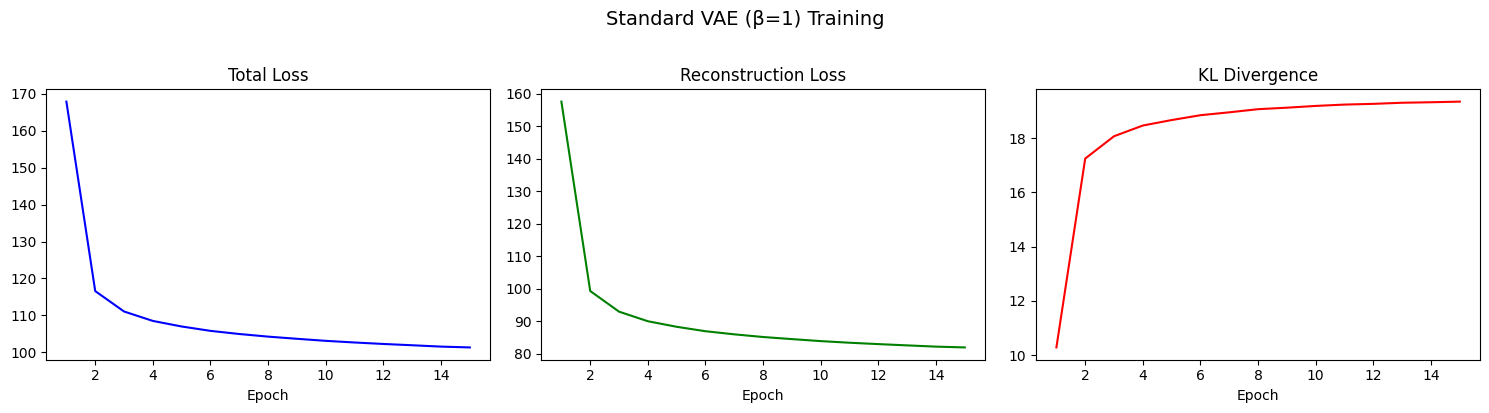

In [5]:
# Plot training curves: we expect reconstruction loss to decrease steadily
# while KL divergence increases as the model learns to use the latent space.
fig = plot_loss_curves(metrics_b1, title="Standard VAE (β=1) Training",
                       save_path=EVIDENCE_DIR / "loss_curves_beta1.png")
plt.show()

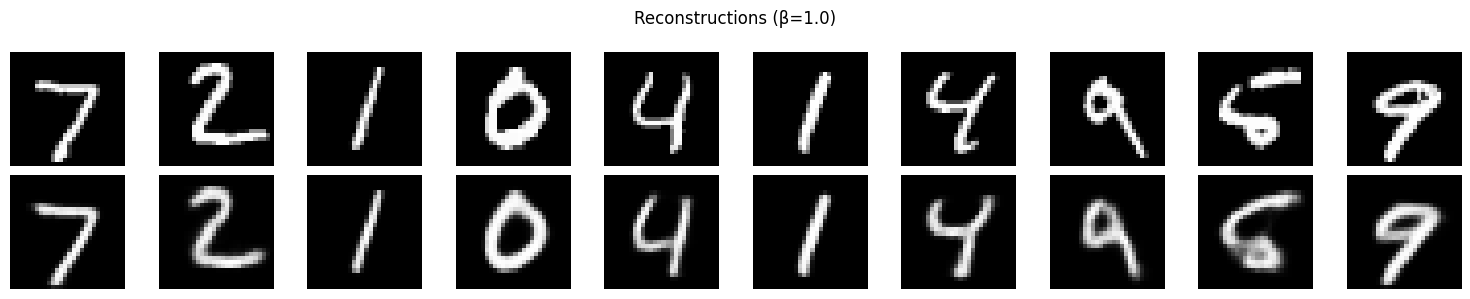

In [6]:
# Visual inspection: compare original test images (top) vs. reconstructions (bottom).
# Good reconstructions preserve digit identity and gross structure; fine details
# (exact stroke edges) are typically lost due to the information bottleneck.
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(DEVICE)

fig = plot_reconstructions(model_b1, test_images, n_show=10,
                           save_path=EVIDENCE_DIR / "reconstructions_beta1.png")
plt.show()

## 5. Effect of β on Disentanglement

Now we train three additional models at β ∈ {0.5, 4.0, 10.0} and compare against the β=1 baseline. The core hypothesis from [Higgins et al., 2017](https://openreview.net/forum?id=Sy2fzU9gl) is:

> Increasing β beyond 1 applies stronger pressure on the latent bottleneck, encouraging the model to learn a more **efficient, factored representation** where individual latent dimensions align with independent generative factors.

The trade-off is clear: with limited latent capacity, stronger regularization forces the model to prioritize which information to encode, leading to:
- **Lower KL divergence** (posterior closer to the unit Gaussian prior)
- **Higher reconstruction loss** (less information passes through the bottleneck)
- **More structured latent geometry** (better for downstream tasks and interpolation)

In [7]:
# Train models at three additional β values.
# β=0.5: under-regularized (sharper reconstructions, less structure)
# β=4.0: moderately disentangled (good balance point)
# β=10.0: aggressively regularized (very structured latent space, blurry outputs)
beta_values = [0.5, 4.0, 10.0]
models = {1.0: model_b1}
all_metrics = {1.0: metrics_b1}

for beta in beta_values:
    print(f"\n--- Training β={beta} ---")
    model = BetaVAE(latent_dim=LATENT_DIM, beta=beta).to(DEVICE)
    metrics = train_model(model, train_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE)
    models[beta] = model
    all_metrics[beta] = metrics
    
    # Report test metrics for each β
    t_total, t_recon, t_kl = evaluate(model, test_loader, device=DEVICE)
    print(f"  Test: total={t_total:.2f}, recon={t_recon:.2f}, KL={t_kl:.2f}")

print("\nAll models trained.")


--- Training β=0.5 ---
  Test: total=91.11, recon=79.24, KL=23.75

--- Training β=4.0 ---
  Test: total=143.73, recon=109.21, KL=8.63

--- Training β=10.0 ---
  Test: total=181.58, recon=142.87, KL=3.87

All models trained.


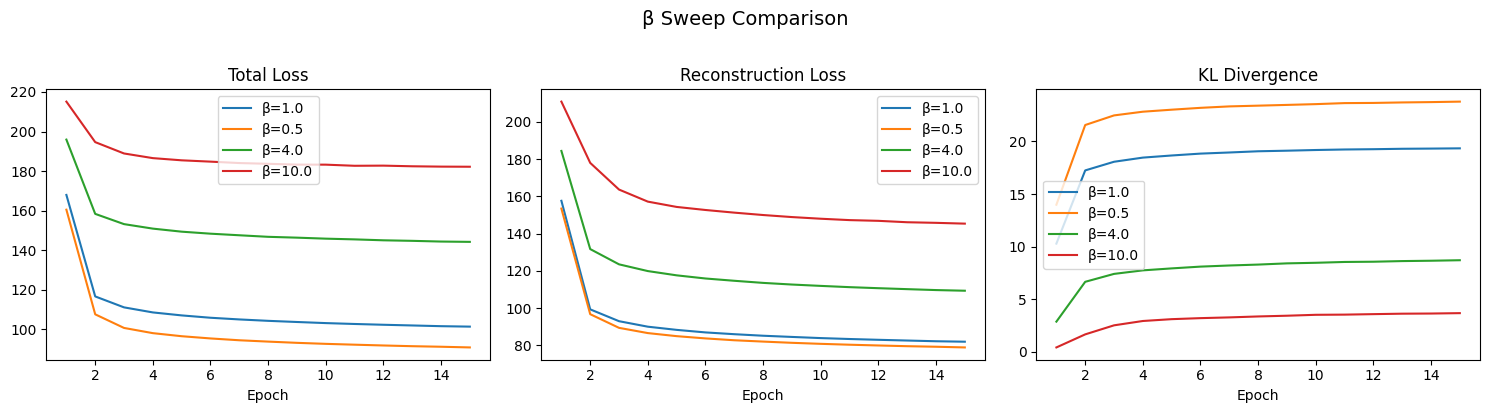

In [8]:
# Compare training dynamics across β values.
# Key observation: higher β models show lower KL but higher reconstruction loss,
# confirming the theoretical trade-off.
fig = plot_beta_comparison(all_metrics, save_path=EVIDENCE_DIR / "beta_comparison.png")
plt.show()

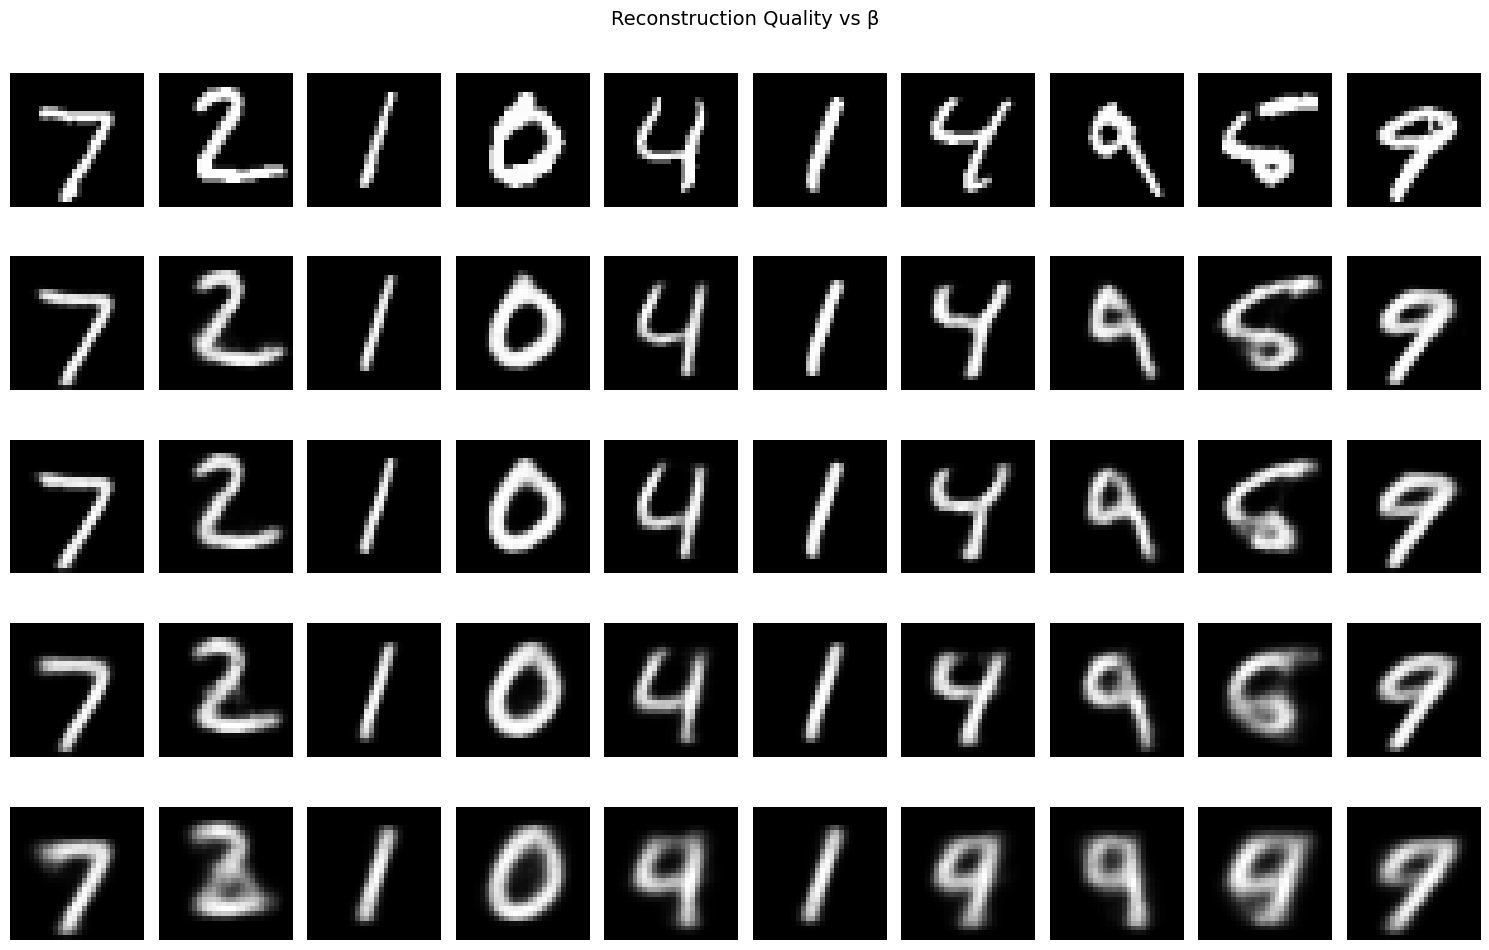

In [9]:
# Side-by-side reconstruction comparison across all β values.
# Row 0: original test images
# Rows 1-4: reconstructions at β=0.5, 1.0, 4.0, 10.0
# Visual progression: β=0.5 is sharpest; β=10.0 is blurriest but most "averaged"
fig, axes = plt.subplots(len(models) + 1, 10, figsize=(15, 2 * (len(models) + 1)))

# Display the first 10 original test images in the top row
sample_images = test_images[:10]
for i in range(10):
    axes[0, i].imshow(sample_images[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)

# For each β value, reconstruct the same 10 images and display in subsequent rows
for row, beta in enumerate(sorted(models.keys()), 1):
    recon = models[beta].reconstruct(sample_images).cpu().numpy()
    for i in range(10):
        axes[row, i].imshow(recon[i, 0], cmap="gray")  # Channel 0 of grayscale output
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(f"β={beta}", fontsize=9)  # Label each row with its β value

plt.suptitle("Reconstruction Quality vs β", fontsize=14)
plt.tight_layout()
fig.savefig(EVIDENCE_DIR / "reconstruction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Latent Space Visualization

To understand *how* the latent space changes with β, we encode all 10,000 test images and project onto the first two latent dimensions ($z_1$ and $z_2$).

**What to look for:**
- **Low β (0.5):** Scattered, class-separated clusters — the encoder uses latent dimensions freely to separate classes, but the space is not Gaussian-shaped, making random sampling unreliable.
- **β=1 (standard VAE):** Moderate overlap — classes partially merge but the space begins to resemble the prior.
- **High β (4.0, 10.0):** Tight, overlapping, Gaussian-shaped distribution — sampling from $\mathcal{N}(0, I)$ reliably produces recognizable digits, but class separability in latent space is reduced.

This is a visual confirmation of the **information-theoretic** tension: stronger regularization (higher β) compresses the mutual information $I(x; z)$ between data and codes, forcing the encoder to "forget" fine-grained distinctions ([Alemi et al., 2018](https://arxiv.org/abs/1711.00464)).

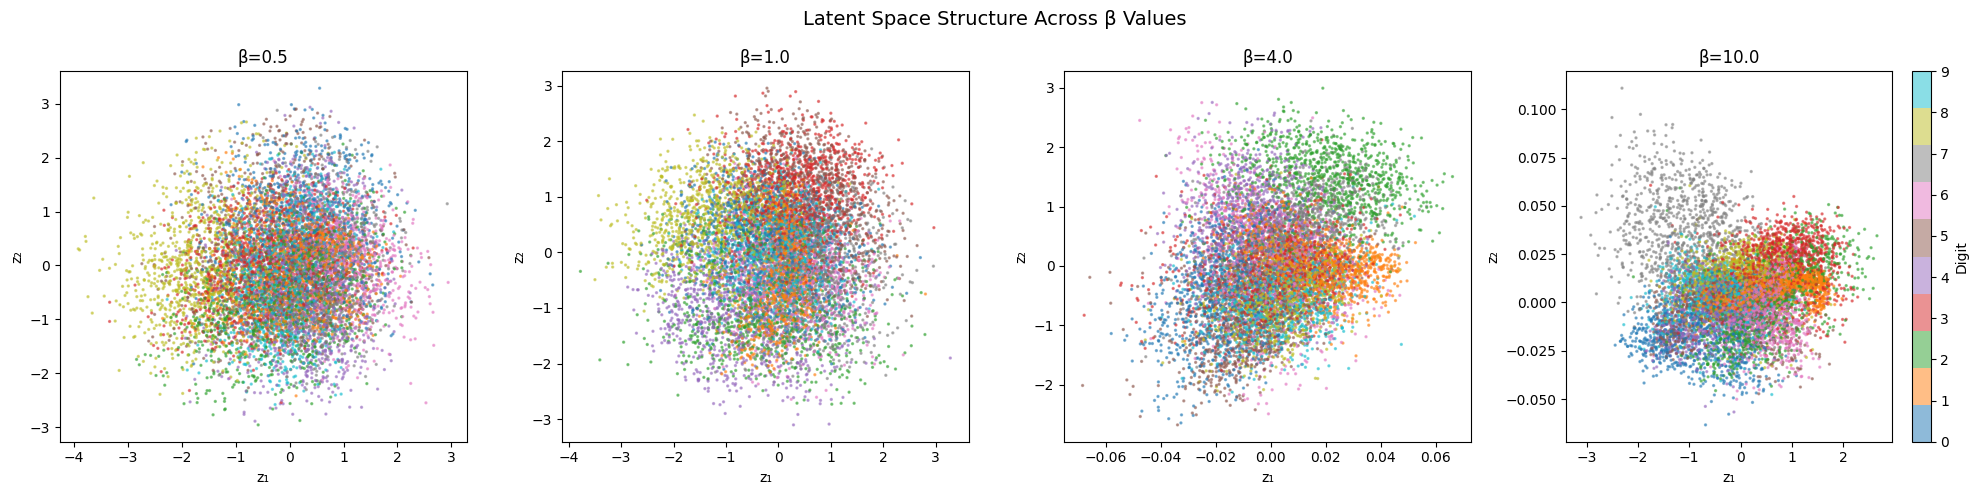

In [10]:
# Encode all test images and visualize the first two latent dimensions.
# Color = digit class (0-9). We use the mean μ (not a sample) for cleaner visualization.
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, beta in zip(axes, sorted(models.keys())):
    model = models[beta]
    model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():  # No gradients needed for inference
        for imgs, lbls in test_loader:
            mu, _ = model.encoder(imgs.to(DEVICE))  # Extract mean of q(z|x)
            all_mu.append(mu.cpu())
            all_labels.append(lbls)
    mu_cat = torch.cat(all_mu).numpy()
    labels_cat = torch.cat(all_labels).numpy()
    
    scatter = ax.scatter(mu_cat[:, 0], mu_cat[:, 1], c=labels_cat, cmap="tab10", s=2, alpha=0.5)
    ax.set_title(f"β={beta}")
    ax.set_xlabel("z₁")
    ax.set_ylabel("z₂")

plt.colorbar(scatter, ax=axes[-1], label="Digit")
plt.suptitle("Latent Space Structure Across β Values", fontsize=14)
plt.tight_layout()
fig.savefig(EVIDENCE_DIR / "latent_space_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Latent Interpolation

One of the most compelling properties of VAEs is their ability to produce **smooth interpolations** between data points in latent space. Given two encoded digits $z_a$ and $z_b$, we linearly interpolate:

$$z_\alpha = (1 - \alpha)\, z_a + \alpha\, z_b, \quad \alpha \in [0, 1]$$

and decode each intermediate point. A well-structured latent space produces semantically meaningful transitions (e.g., a "3" smoothly morphing into a "7" through intermediate digit-like forms).

**Higher β should produce smoother transitions** because the regularized latent space has fewer "holes" — regions where the decoder has never seen training data and might produce artifacts. This is a practical benefit of disentanglement: the latent manifold is more uniformly covered.

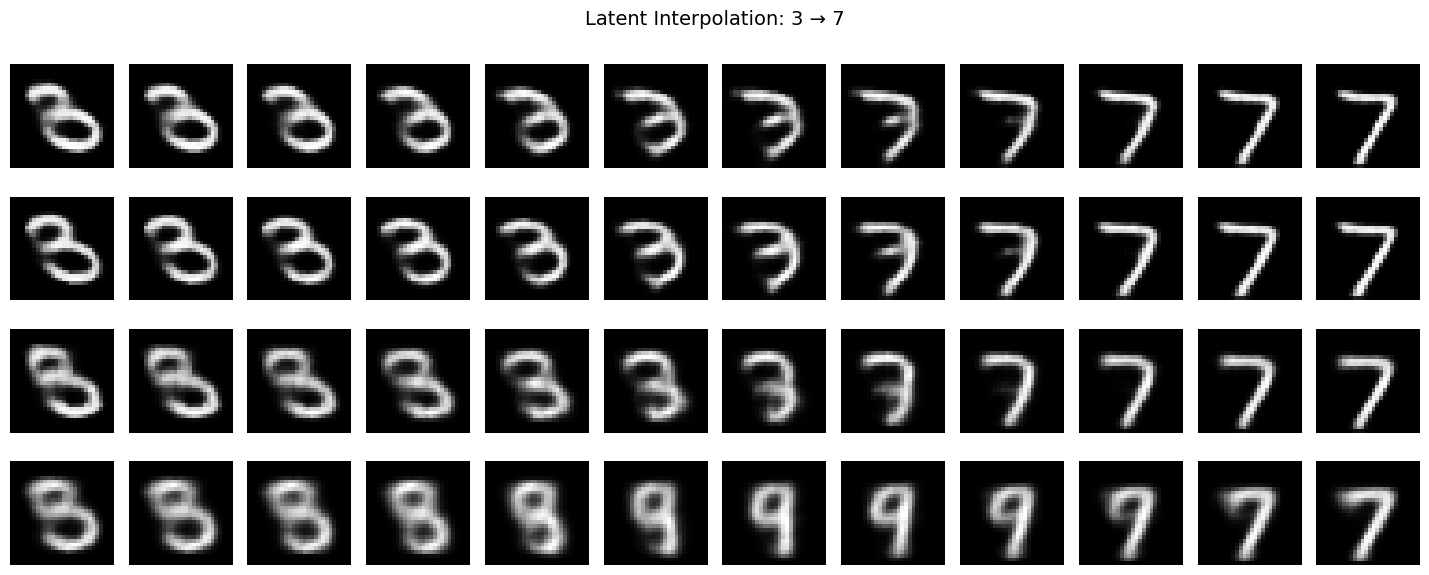

In [11]:
# Find one example of a '3' and a '7' in the test set to interpolate between.
# These digits are chosen because they share some structure (the top bar)
# but differ significantly, making the transition informative.
idx_3 = next(i for i, (_, l) in enumerate(test_dataset) if l == 3)
idx_7 = next(i for i, (_, l) in enumerate(test_dataset) if l == 7)

img_3 = test_dataset[idx_3][0].unsqueeze(0).to(DEVICE)  # Add batch dimension
img_7 = test_dataset[idx_7][0].unsqueeze(0).to(DEVICE)

N_STEPS = 12  # Number of interpolation points including endpoints
fig, axes = plt.subplots(len(models), N_STEPS, figsize=(N_STEPS * 1.2, len(models) * 1.5))

for row, beta in enumerate(sorted(models.keys())):
    model = models[beta]
    model.eval()
    with torch.no_grad():
        z_3, _ = model.encoder(img_3)  # Encode: get latent mean for digit 3
        z_7, _ = model.encoder(img_7)  # Encode: get latent mean for digit 7
    
    # Linear interpolation in latent space
    alphas = torch.linspace(0, 1, N_STEPS).unsqueeze(1).to(DEVICE)
    z_interp = z_3 * (1 - alphas) + z_7 * alphas
    
    # Decode each interpolated latent vector back to image space
    with torch.no_grad():
        decoded = model.decoder(z_interp).cpu().numpy()
    
    for i in range(N_STEPS):
        axes[row, i].imshow(decoded[i, 0], cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(f"β={beta}", fontsize=9)

plt.suptitle("Latent Interpolation: 3 → 7", fontsize=14)
plt.tight_layout()
fig.savefig(EVIDENCE_DIR / "latent_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Generation Quality

The ultimate test of a generative model is whether it can produce **novel, realistic samples** from the learned distribution. We draw latent vectors from the prior $z \sim \mathcal{N}(0, I)$ and decode them.

A well-regularized model (higher β) should produce more recognizable samples because its latent space closely matches the prior — random draws land in regions the decoder has learned to map to digit-like outputs. Conversely, an under-regularized model (low β) may have a latent space that deviates significantly from $\mathcal{N}(0, I)$, causing random samples to fall in "dead zones" the decoder cannot handle.

We use the **same random latent vectors** across all models to enable direct visual comparison.

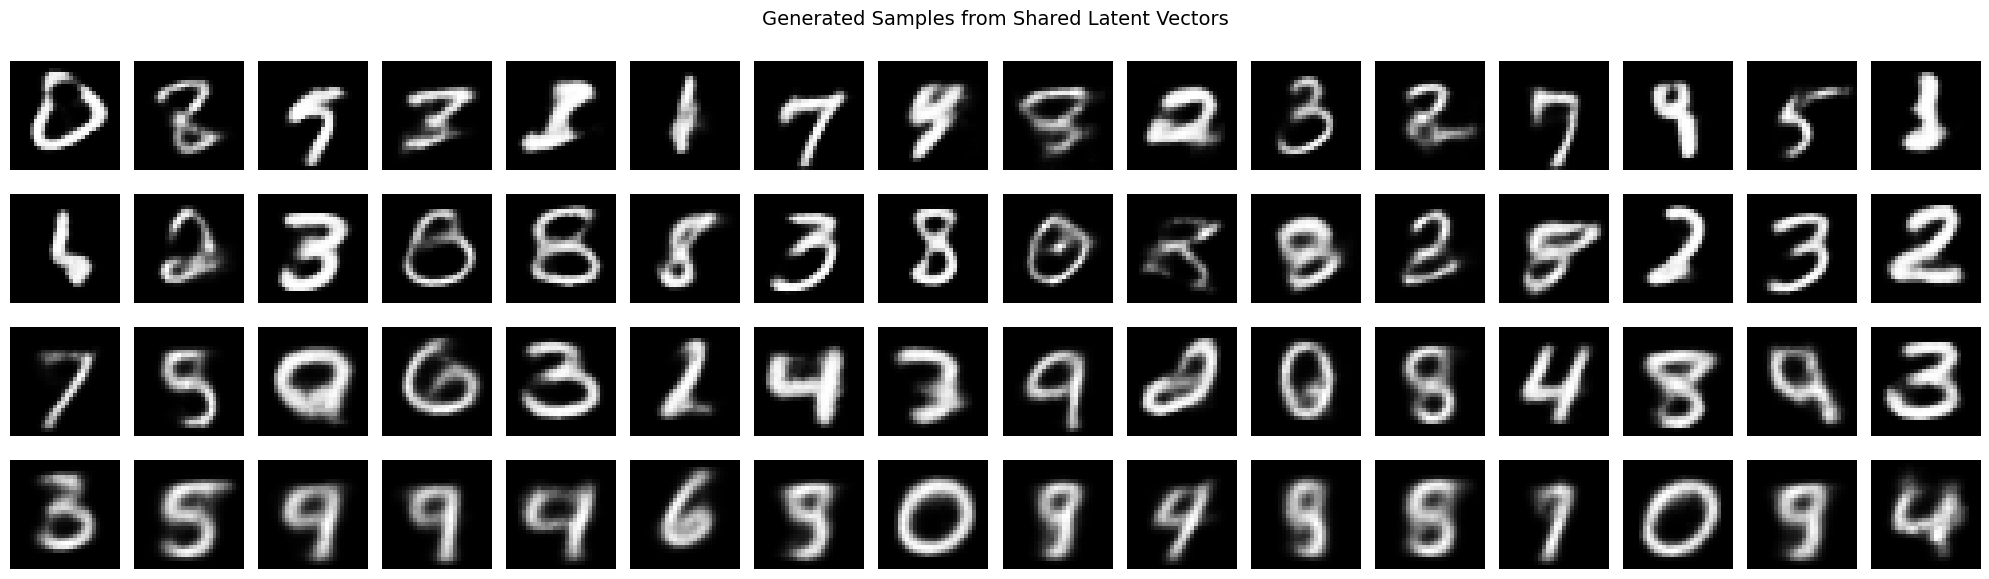

In [12]:
# Generate samples from the prior using the same random seed for all models.
# z_shared: 16 random latent vectors drawn from N(0, I).
fig, axes = plt.subplots(len(models), 16, figsize=(20, len(models) * 1.5))

torch.manual_seed(42)  # Fixed seed for reproducible comparison
z_shared = torch.randn(16, LATENT_DIM).to(DEVICE)

for row, beta in enumerate(sorted(models.keys())):
    model = models[beta]
    model.eval()
    with torch.no_grad():
        samples = model.decoder(z_shared).cpu().numpy()  # Decode prior samples
    for i in range(16):
        axes[row, i].imshow(samples[i, 0], cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_ylabel(f"β={beta}", fontsize=9)

plt.suptitle("Generated Samples from Shared Latent Vectors", fontsize=14)
plt.tight_layout()
fig.savefig(EVIDENCE_DIR / "generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Quantitative summary: test-set losses broken down by component.
# The reconstruction-KL trade-off should be clearly visible in the numbers.
import pandas as pd

rows = []
for beta in sorted(models.keys()):
    # Evaluate each model on held-out test data
    t_total, t_recon, t_kl = evaluate(models[beta], test_loader, device=DEVICE)
    # Build one row per β value with all three loss components
    rows.append({"β": beta, "Total Loss": f"{t_total:.2f}", "Recon Loss": f"{t_recon:.2f}", "KL Div": f"{t_kl:.2f}"})

df = pd.DataFrame(rows)
print("\n=== Test Metrics Summary ===")
print(df.to_string(index=False))


=== Test Metrics Summary ===
   β Total Loss Recon Loss KL Div
 0.5      91.19      79.31  23.75
 1.0     101.60      82.65  18.95
 4.0     143.60     109.08   8.63
10.0     181.88     143.17   3.87


## 9. Key Findings and Takeaways

### The Reconstruction–Disentanglement Trade-off Is Real and Measurable

As β increases from 0.5 to 10.0, we observe a clear, monotonic trade-off:
- **Reconstruction loss increases** — the model has less capacity to encode fine details through the tighter bottleneck
- **KL divergence decreases** — the approximate posterior is pushed closer to the unit Gaussian prior

This confirms the theoretical prediction of [Higgins et al., 2017](https://openreview.net/forum?id=Sy2fzU9gl) and validates that β provides a smooth, controllable knob for navigating this trade-off.

### Latent Space Geometry Reflects the β Setting

- **β=0.5:** Widely scattered clusters with clear class separation — useful for classification but poor for generation (prior mismatch)
- **β=1.0:** Moderate structure — the standard VAE's compromise
- **β=4.0–10.0:** Tight, overlapping, approximately Gaussian — excellent for generation and interpolation, but digit classes overlap in latent space

### Interpolations Improve with Disentanglement

Higher-β models produce smoother, more semantically meaningful transitions when interpolating between encoded digits. This suggests the latent manifold is more **uniformly covered** — a practical requirement for applications like data augmentation and creative exploration.

### Practical Guidance

| Use Case | Recommended β | Rationale |
|----------|:------------:|:---------:|
| Reconstruction / compression | 0.5–1.0 | Maximize fidelity |
| Balanced generation | 1.0–2.0 | Standard VAE trade-off |
| Disentangled representations | 4.0–10.0 | Interpretable, factored codes |
| Downstream transfer learning | 4.0+ | Independent factors generalize better |

### Implementation Notes

- The **reparameterization trick** ([Kingma & Welling, 2014](https://arxiv.org/abs/1312.6114)) is essential — it enables gradient flow through the stochastic sampling step, making end-to-end training possible with standard backpropagation.
- **Convolutional architecture** preserves spatial structure and dramatically improves reconstruction quality over fully-connected alternatives for image data.
- All code is modular (`src/models.py`, `src/training.py`, `src/visualization.py`) with 19 passing tests via `pytest`.

## 10. References

1. **Kingma, D. P., & Welling, M.** (2014). Auto-Encoding Variational Bayes. *ICLR 2014*. [arXiv:1312.6114](https://arxiv.org/abs/1312.6114)  
   — The foundational VAE paper introducing the reparameterization trick and ELBO objective.

2. **Higgins, I., Matthey, L., Pal, A., et al.** (2017). β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework. *ICLR 2017*. [OpenReview](https://openreview.net/forum?id=Sy2fzU9gl)  
   — Introduces the β coefficient and demonstrates that β > 1 encourages disentangled representations.

3. **Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al.** (2014). Generative Adversarial Nets. *NeurIPS 2014*. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)  
   — The original GAN paper, providing context for the VAE's alternative approach to generation.

4. **Bengio, Y., Courville, A., & Vincent, P.** (2013). Representation Learning: A Review and New Perspectives. *IEEE TPAMI*. [arXiv:1206.5538](https://arxiv.org/abs/1206.5538)  
   — Defines disentangled representations and their role in transfer learning.

5. **Alemi, A. A., Poole, B., Fischer, I., et al.** (2018). Fixing a Broken ELBO. *ICML 2018*. [arXiv:1711.00464](https://arxiv.org/abs/1711.00464)  
   — Information-theoretic analysis of the VAE objective; explains β-VAE through the lens of the information bottleneck.

6. **Ho, J., Jain, A., & Abbeel, P.** (2020). Denoising Diffusion Probabilistic Models. *NeurIPS 2020*. [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)  
   — Diffusion models as a modern alternative to VAEs for high-quality generation.

7. **Doersch, C.** (2016). Tutorial on Variational Autoencoders. [arXiv:1606.05908](https://arxiv.org/abs/1606.05908)  
   — An excellent pedagogical introduction to VAEs covering both theory and implementation.